# Bài thực hành: Tạo nhiễu (Noise) và quan sát bằng Fourier Transform

Trong xử lý ảnh kỹ thuật số, biến đổi Fourier 2D (2D Fourier Transform) là một công cụ toán học mạnh mẽ giúp chuyển đổi tín hiệu từ **miền không gian (Spatial Domain)** sang **miền tần số (Frequency Domain)**. 

Bài thực hành này minh họa cách tạo các loại nhiễu phổ biến (**Gaussian, Salt & Pepper, Speckle, Poisson, Periodic**) trên ảnh xám và phân tích đặc trưng phổ tần số của chúng.

### 1. Import các thư viện cần thiết

- **`cv2` (OpenCV)**: Đọc ảnh, chuyển đổi hệ màu và xử lý ảnh cơ bản.
- **`numpy`**: Xử lý ma trận số học và thực hiện biến đổi Fourier nhanh 2D (`np.fft.fft2`, `np.fft.fftshift`).
- **`matplotlib.pyplot`**: Hiển thị trực quan ảnh và các phổ biên độ/pha.

In [25]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

### 2. Đọc và tiền xử lý ảnh đầu vào

Bước này thực hiện:
1. Đọc ảnh từ đường dẫn `dataset/absback_img_06.jpg`.
2. Kiểm tra tính hợp lệ của dữ liệu ảnh.
3. Chuyển đổi từ hệ màu **BGR** mặc định của OpenCV sang **RGB** (để hiển thị bằng Matplotlib) và **Grayscale** (ảnh xám một kênh dùng cho biến đổi Fourier).

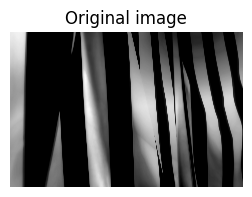

In [31]:
image_path = "dataset/absback_img_06.jpg"

img_bgr = cv2.imread(image_path)

if img_bgr is None:
    raise ValueError("Không đọc được ảnh. Kiểm tra lại image_path.")

img_rgb = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(3, 3))
plt.imshow(img_gray, cmap="gray")
plt.title("Original image")
plt.axis("off")
plt.show()

### 3. Định nghĩa hàm biến đổi Fourier 2D

Hàm `fourier_transform_frequency_domain` thực hiện chuỗi thao tác:
1. **Chuyển đổi kiểu dữ liệu**: Đưa ma trận ảnh xám về dạng số thực `float32`.
2. **Biến đổi Fourier nhanh 2D (`np.fft.fft2`)**: Tính toán phổ tần số phức của ảnh.
3. **Dịch tâm (`np.fft.fftshift`)**: Dịch chuyển thành phần tần số bằng 0 (DC component) từ các góc về trung tâm ma trận phổ.
4. **Tính phổ biên độ (Magnitude Spectrum)**: Dùng thang đo logarit để nén dải động, giúp hiển thị rõ các thành phần tần số có năng lượng thấp:
   $$\text{Magnitude}(u, v) = 20 \cdot \log\left(1 + |F(u, v)|\right)$$
5. **Tính phổ pha (Phase Spectrum)**: Lấy góc pha của số phức bằng `np.angle`.

In [32]:
def fourier_transform_frequency_domain(image, color_space="BGR", visualize=True, figsize=(15, 5)):
    """Transform an image to the frequency domain with 2D Fourier Transform."""
    if image is None:
        raise ValueError("Input image is None.")

    if isinstance(image, str):
        gray_image = cv2.imread(image, cv2.IMREAD_GRAYSCALE)
        if gray_image is None:
            raise ValueError(f"Cannot read image from path: {image}")
    else:
        image_array = np.asarray(image)

        if image_array.ndim == 2:
            gray_image = image_array.copy()
        elif image_array.ndim == 3 and image_array.shape[2] >= 3:
            conversion = cv2.COLOR_RGB2GRAY if color_space.upper() == "RGB" else cv2.COLOR_BGR2GRAY
            gray_image = cv2.cvtColor(image_array[:, :, :3], conversion)
        else:
            raise ValueError("Image must be a path, a grayscale image, or a 3-channel color image.")

    gray_float = gray_image.astype(np.float32)
    fft_image = np.fft.fft2(gray_float)
    fft_shifted = np.fft.fftshift(fft_image)

    magnitude_spectrum = 20 * np.log1p(np.abs(fft_shifted))
    phase_spectrum = np.angle(fft_shifted)

    if visualize:
        show_images(
            [gray_image, magnitude_spectrum, phase_spectrum],
            ["Spatial domain", "Magnitude spectrum", "Phase spectrum"],
            cmap="gray",
            figsize=figsize,
        )

    return {
        "gray_image": gray_image,
        "fft_image": fft_image,
        "fft_shifted": fft_shifted,
        "magnitude_spectrum": magnitude_spectrum,
        "phase_spectrum": phase_spectrum,
    }

### 4. Phân tích phổ Fourier của ảnh gốc

Thực hiện biến đổi Fourier trên ảnh gốc chưa thêm nhiễu để làm mốc chuẩn (baseline) so sánh với các ảnh bị nhiễu.

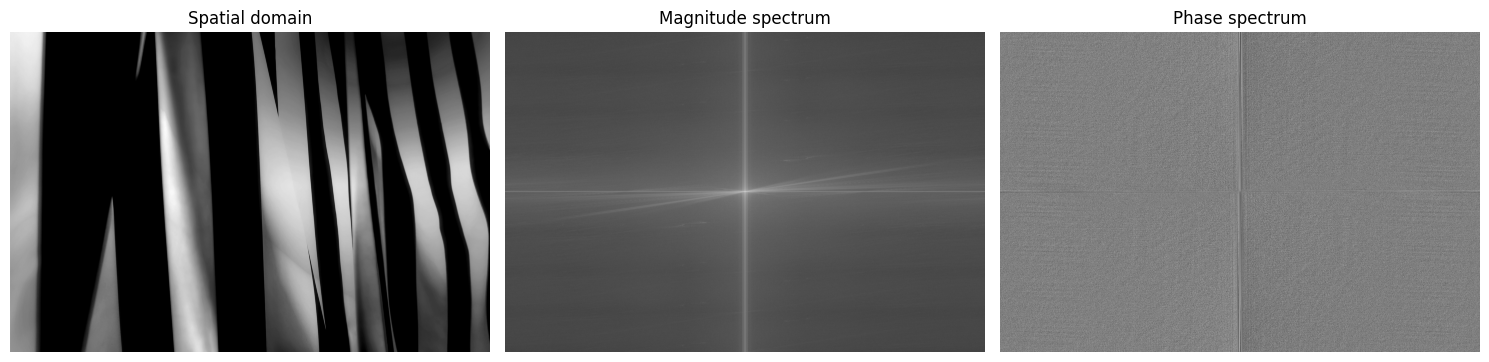

In [33]:
frequency_result = fourier_transform_frequency_domain(img_gray)

### 5. Định nghĩa hàm tiện ích hiển thị nhiều ảnh

Hàm `show_images` sắp xếp các ảnh trên cùng một hàng ngang nhằm thuận tiện cho việc so sánh trực quan giữa ảnh không gian và phổ tương ứng.

In [34]:
def show_images(images, titles, cmap="gray", figsize=(15, 5)):
    plt.figure(figsize=figsize)

    for i, (image, title) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        plt.imshow(image, cmap=cmap)
        plt.title(title)
        plt.axis("off")

    plt.tight_layout()
    plt.show()

---
### 6. Tạo nhiễu cộng Gaussian (Gaussian Noise)

**Gaussian noise** là loại nhiễu cộng ngẫu nhiên tuân theo phân phối chuẩn (Gaussian distribution), thường xuất hiện do nhiễu nhiệt trong cảm biến máy ảnh hoặc mạch khuếch đại:

$$I_{\text{noisy}}(x, y) = I(x, y) + N(x, y)$$

Trong đó $N(x, y) \sim \mathcal{N}(\mu, \sigma^2)$ là giá trị nhiễu có giá trị kỳ vọng $\mu$ (thường bằng 0) và độ lệch chuẩn $\sigma$.

*Đoạn mã dưới đây sinh nhiễu Gaussian bằng `np.random.normal`, cộng vào ảnh gốc và kẹp (clip) giá trị trong khoảng `[0, 255]`.*

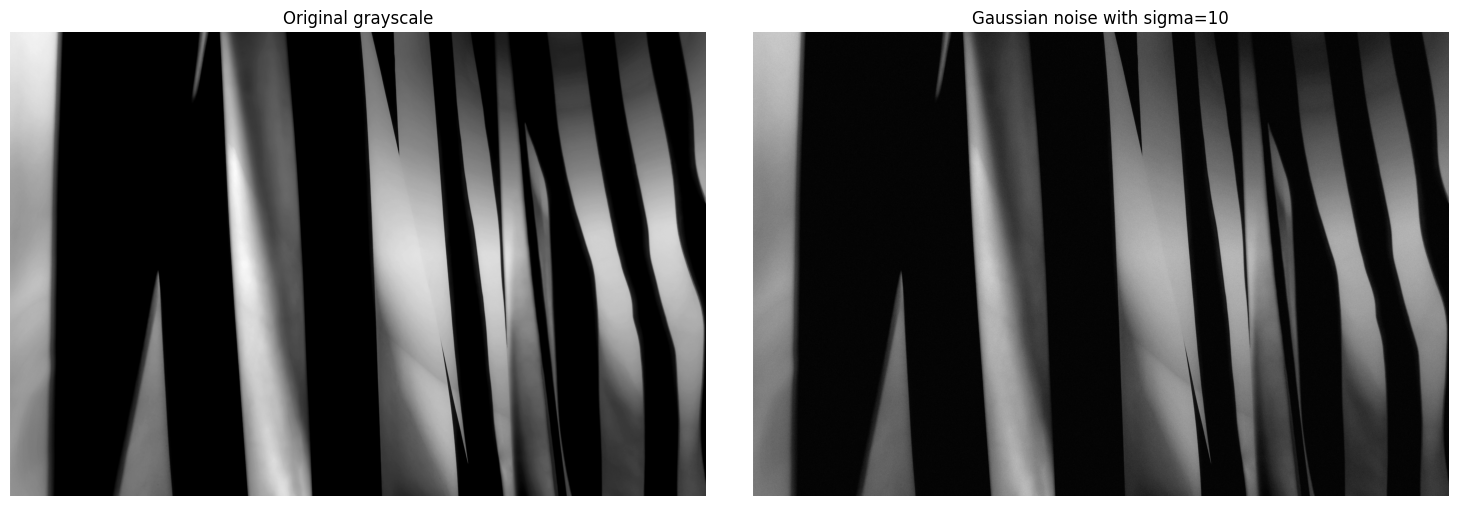

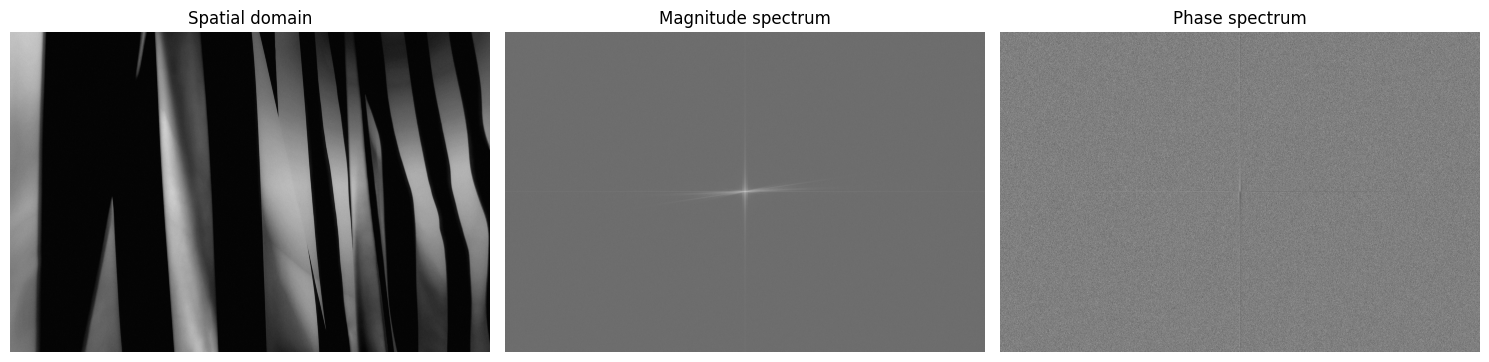

In [37]:
def add_gaussian_noise(image, mean=0, sigma=25):
    image_float = image.astype(np.float32)

    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image_float + noise

    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8), sigma

gaussian_noisy, sigma = add_gaussian_noise(img_gray, mean=0, sigma = 10) # Change sigma values

show_images(
    [img_gray, gaussian_noisy],
    ["Original grayscale", f"Gaussian noise with sigma={sigma}"]
)

gaussian_noisy_frequency_result = fourier_transform_frequency_domain(gaussian_noisy)

---
### 7. Tạo nhiễu Muối Tiêu (Salt & Pepper Noise)

**Salt & Pepper noise** là loại nhiễu xung (impulse noise), xảy ra khi tín hiệu bị hỏng đột ngột tại một số điểm ảnh (do lỗi truyền tải hoặc khuyết tật cảm biến). Điểm ảnh bị nhiễu sẽ biến thành màu trắng cực đại (**Muối - Salt**: giá trị 255) hoặc màu đen cực tiểu (**Tiêu - Pepper**: giá trị 0):

$$I_{\text{noisy}}(x, y) = \begin{cases} 255 & \text{với xác suất } \frac{p}{2} \\ 0 & \text{với xác suất } \frac{p}{2} \\ I(x, y) & \text{với xác suất } 1 - p \end{cases}$$

Trong đó $p$ là tổng mật độ điểm ảnh bị nhiễu (`amount`).

*Đoạn mã dưới đây lựa chọn ngẫu nhiên các tọa độ `(y, x)` trên ảnh để gán giá trị 255 hoặc 0.*

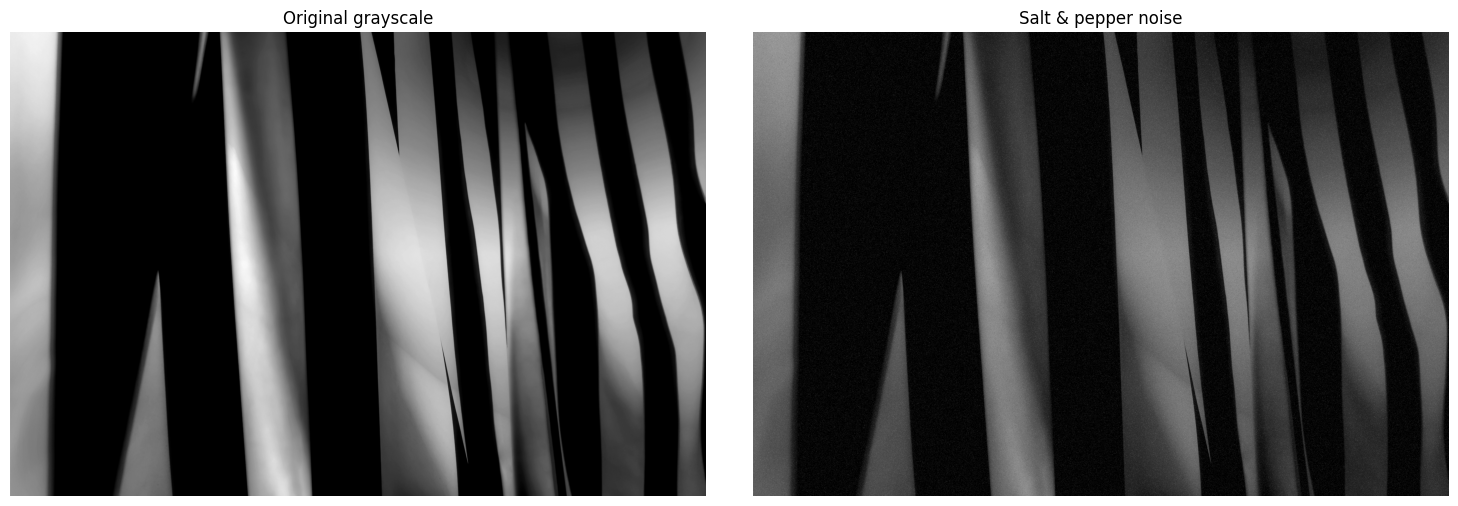

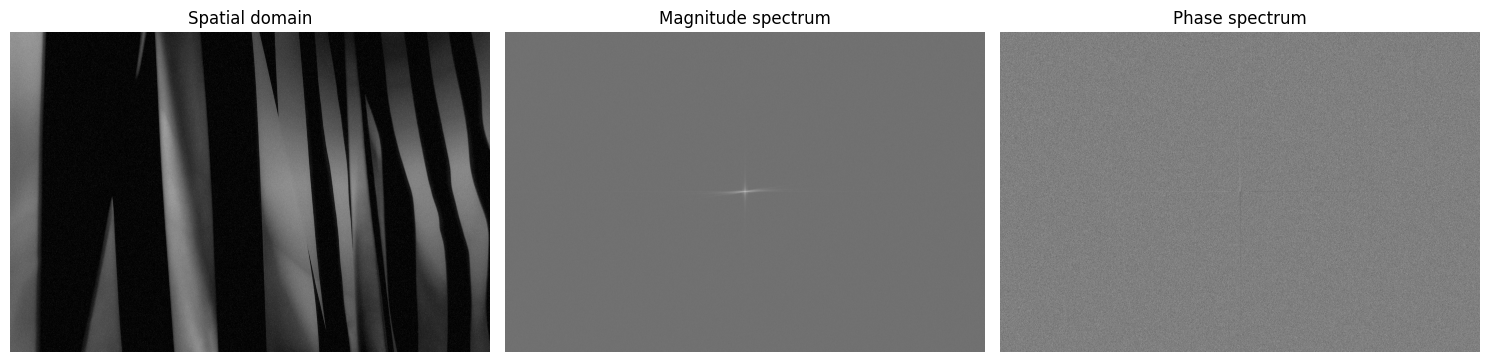

In [38]:
def add_salt_pepper_noise(image, amount=0.03, salt_vs_pepper=0.5):
    noisy = image.copy()

    h, w = image.shape
    num_pixels = h * w

    num_salt = int(amount * num_pixels * salt_vs_pepper)
    num_pepper = int(amount * num_pixels * (1 - salt_vs_pepper))

    # Salt: pixel trắng
    ys = np.random.randint(0, h, num_salt)
    xs = np.random.randint(0, w, num_salt)
    noisy[ys, xs] = 255

    # Pepper: pixel đen
    ys = np.random.randint(0, h, num_pepper)
    xs = np.random.randint(0, w, num_pepper)
    noisy[ys, xs] = 0

    return noisy

sp_noisy = add_salt_pepper_noise(img_gray, amount=0.05)

show_images(
    [img_gray, sp_noisy],
    ["Original grayscale", "Salt & pepper noise"]
)

sp_noisy_frequency_result = fourier_transform_frequency_domain(sp_noisy)

---
### 8. Tạo nhiễu Đốm (Speckle Noise)

**Speckle noise** là loại nhiễu nhân (multiplicative noise), đặc trưng trong ảnh ra-đa chủ động (SAR), siêu âm y khoa hoặc chụp ảnh bằng tia laser:

$$I_{\text{noisy}}(x, y) = I(x, y) + I(x, y) \cdot N(x, y) = I(x, y) \cdot \big(1 + N(x, y)\big)$$

Trong đó $N(x, y) \sim \mathcal{N}(0, \sigma^2)$ là biến ngẫu nhiên phân phối chuẩn. Do lượng nhiễu tỉ lệ thuận với cường độ sáng $I(x, y)$, các **vùng ảnh sáng sẽ chịu dao động nhiễu mạnh hơn đáng kể so với các vùng tối**.

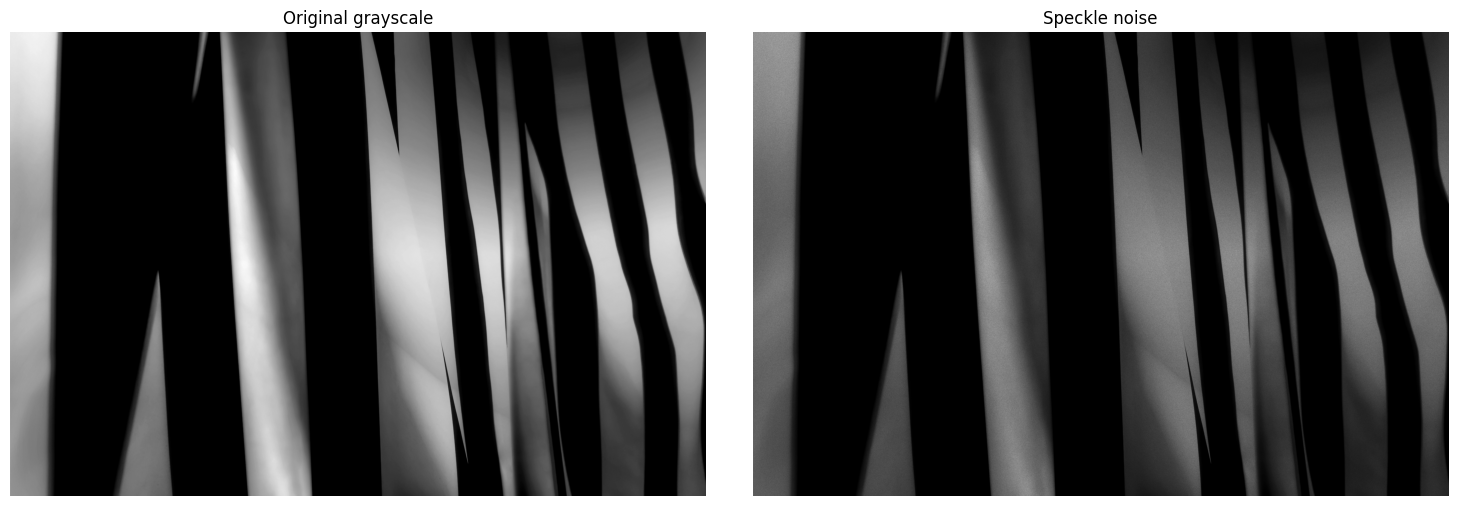

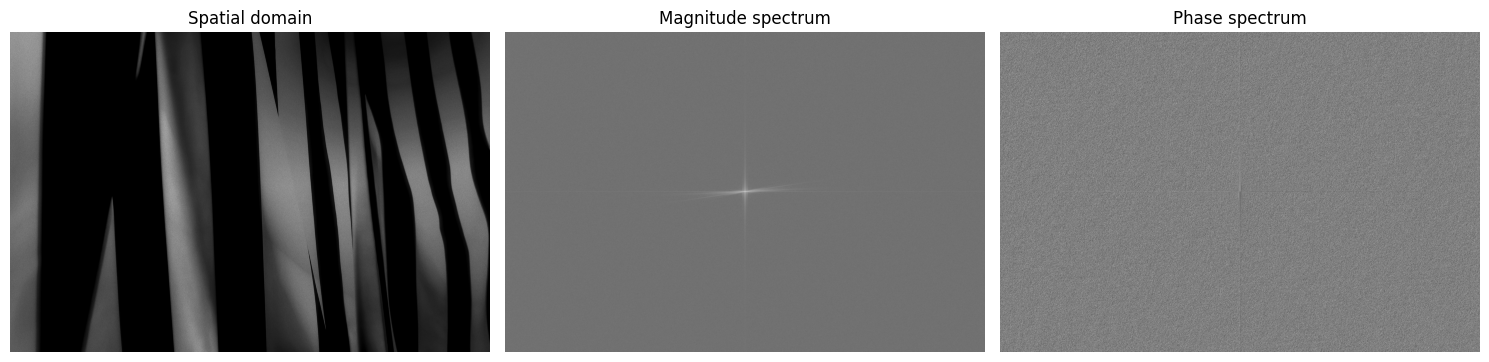

In [40]:
def add_speckle_noise(image, mean=0, sigma=0.2):
    image_float = image.astype(np.float32)

    noise = np.random.normal(mean, sigma, image.shape)
    noisy = image_float + image_float * noise

    noisy = np.clip(noisy, 0, 255)
    return noisy.astype(np.uint8)

speckle_noisy = add_speckle_noise(img_gray, sigma=0.2)

show_images(
    [img_gray, speckle_noisy],
    ["Original grayscale", "Speckle noise"]
)

speckle_noisy_frequency_result = fourier_transform_frequency_domain(speckle_noisy)

---
### 9. Tạo nhiễu Poisson (Poisson Noise / Shot Noise)

**Poisson noise** (hay Shot noise) sinh ra từ sự biến động thống kê ngẫu nhiên của số lượng photon ánh sáng đập vào bề mặt cảm biến trong một khoảng thời gian phơi sáng nhất định. Ảnh chụp trong điều kiện thiếu sáng (low-light) rất nhạy cảm với loại nhiễu này:

$$I_{\text{noisy}}(x, y) \sim \text{Poisson}\big(I(x, y)\big)$$

Đặc tính quan trọng của phân phối Poisson là **phương sai bằng chính giá trị kỳ vọng** ($\sigma^2 = I$). Do đó, độ lệch chuẩn của nhiễu tại mỗi điểm ảnh tỉ lệ thuận với căn bậc hai của cường độ sáng tín hiệu ($\sigma = \sqrt{I}$).

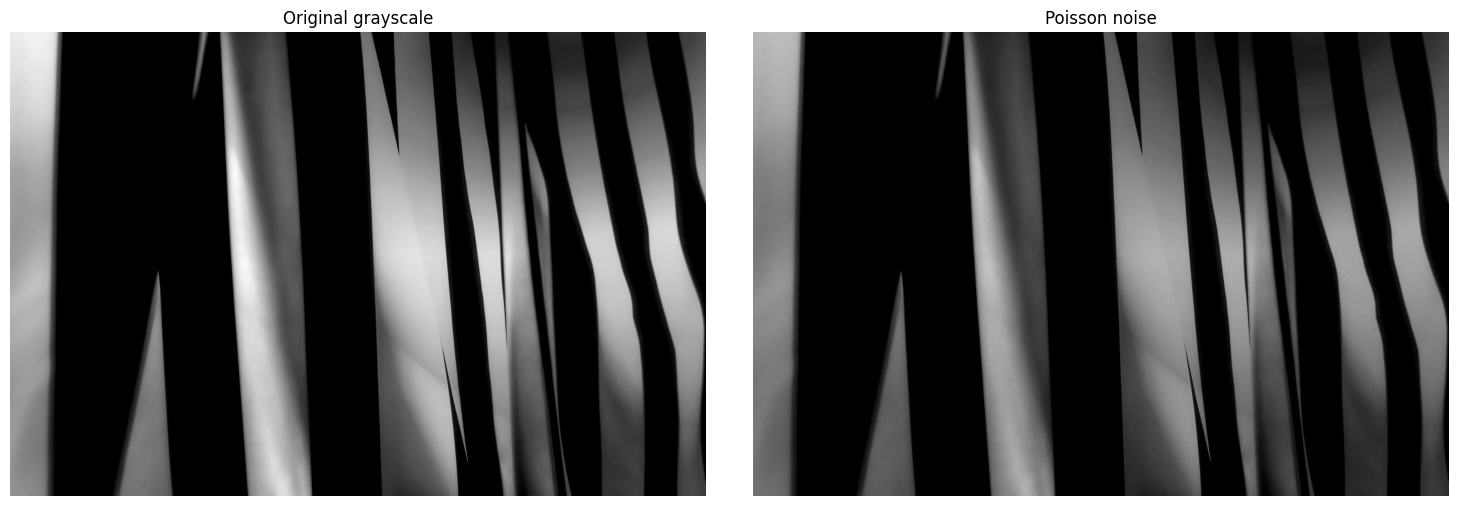

In [41]:
def add_poisson_noise(image):
    image_float = image.astype(np.float32)

    noisy = np.random.poisson(image_float)
    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)

poisson_noisy = add_poisson_noise(img_gray)

show_images(
    [img_gray, poisson_noisy],
    ["Original grayscale", "Poisson noise"]
)

---
### 10. Tạo nhiễu Tuần Hoàn (Periodic / Sinusoidal Noise)

**Periodic noise** xuất hiện khi có sự nhiễu loạn sóng điện từ hoặc nhiễu nguồn điện xoay chiều tác động liên tục vào thiết bị ghi hình, tạo ra các vân sóng tuần hoàn lặp đi lặp lại trên ảnh.

Công thức sóng hài nhiễu theo phương ngang:
$$I_{\text{noisy}}(x, y) = I(x, y) + A \cdot \sin\left(\frac{2\pi f \cdot x}{W}\right)$$

Công thức sóng hài nhiễu theo phương dọc:
$$I_{\text{noisy}}(x, y) = I(x, y) + A \cdot \sin\left(\frac{2\pi f \cdot y}{H}\right)$$

Trong đó $A$ là biên độ dao động (`amplitude`), $f$ là tần số không gian (`frequency`), $W, H$ là chiều rộng và chiều cao của ma trận ảnh.

> **Đặc trưng trên miền tần số (Fourier Transform)**: Khi chuyển sang miền tần số, nhiễu tuần hoàn không phân bố đều mà tập trung toàn bộ năng lượng vào **hai điểm sáng cô lập đối xứng qua tâm phổ biên độ**. Nhờ đặc tính này, ta có thể dễ dàng định vị và khử nhiễu tuần hoàn bằng bộ lọc chắn điểm (Notch Filter) trong miền tần số.

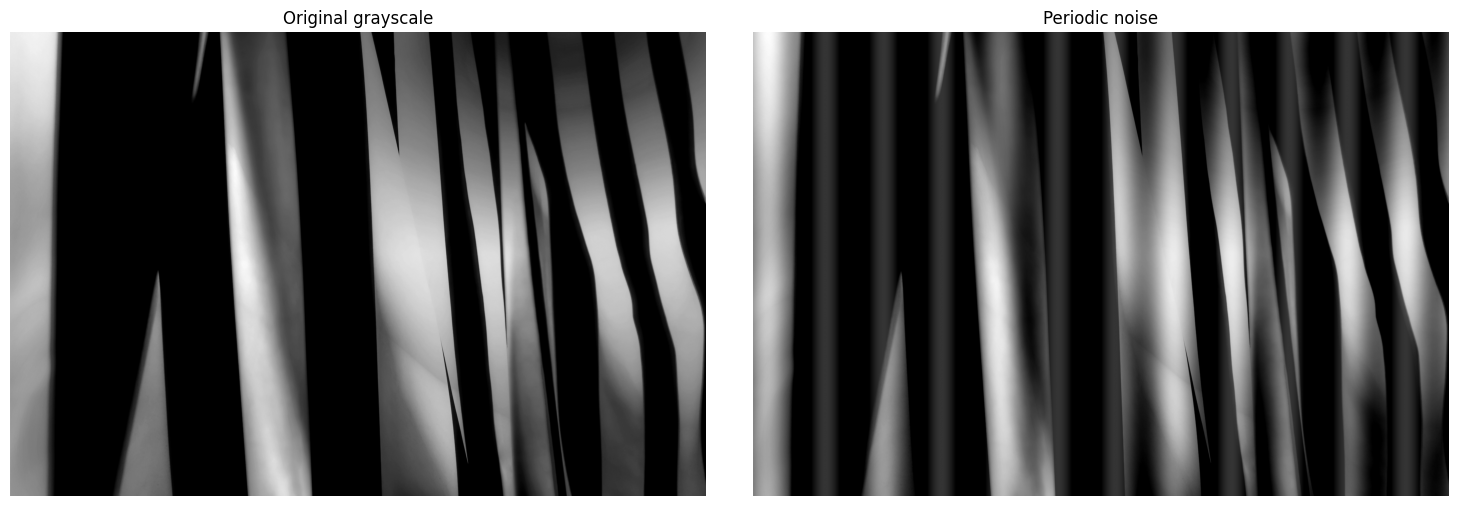

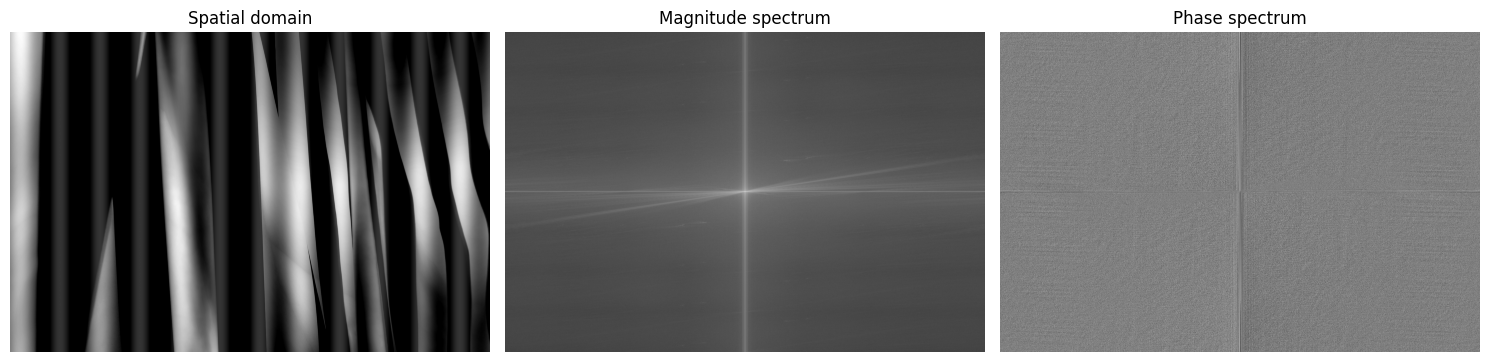

In [42]:
def add_periodic_noise(image, amplitude=40, frequency=10, direction="horizontal"):
    h, w = image.shape

    if direction == "horizontal":
        x = np.arange(w)
        sinusoid = amplitude * np.sin(2 * np.pi * frequency * x / w)
        noise = np.tile(sinusoid, (h, 1))

    elif direction == "vertical":
        y = np.arange(h)
        sinusoid = amplitude * np.sin(2 * np.pi * frequency * y / h)
        noise = np.tile(sinusoid[:, np.newaxis], (1, w))

    else:
        raise ValueError("direction phải là 'horizontal' hoặc 'vertical'")

    noisy = image.astype(np.float32) + noise
    noisy = np.clip(noisy, 0, 255)

    return noisy.astype(np.uint8)

periodic_noisy = add_periodic_noise(
    img_gray,
    amplitude=40,
    frequency=12,
    direction="horizontal"
)

show_images(
    [img_gray, periodic_noisy],
    ["Original grayscale", "Periodic noise"]
)

periodic_noisy_frequency_result = fourier_transform_frequency_domain(periodic_noisy)